<img src="../olist_analytics_banner_1777484524407.png" width="100%" style="border-radius: 15px; margin-bottom: 20px;">

# Olist E-Commerce Analytics: Brazil's Retail Pulse

## Table of Contents
1. [Introduction](#introduction)
2. [Database Schema](#schema)
3. [Setup & Connection](#setup)
4. [High-Level KPIs](#kpis)
5. [Growth & Logistics Trends](#growth)
6. [Geographic Revenue Distribution](#geo)
7. [Customer Satisfaction Analysis](#satisfaction)
8. [Marketplace Mechanics (Sellers & Payments)](#mechanics)
9. [Conclusion](#conclusion)

---

## 1. Introduction
Welcome to a comprehensive deep-dive into the **Brazilian E-Commerce Public Dataset by Olist**. This dataset contains information on 100k orders from 2016 to 2018 made at multiple marketplaces in Brazil.

**Data Source:** [Kaggle - Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

Olist is a Brazilian e-commerce platform that connects small businesses from all over Brazil to channels without hassle. This analysis explores the lifecycle of an order—from payment to delivery—to uncover operational insights and growth patterns.

## 2. Database Schema Visualization
Understanding the data architecture is the first step in any robust analysis. The Olist database is a relational ecosystem centered around the `ORDERS` table.

```mermaid
erDiagram
    CUSTOMERS ||--o{ ORDERS : places
    ORDERS ||--|{ ORDER_ITEMS : contains
    ORDERS ||--|{ ORDER_PAYMENTS : paid_via
    ORDERS ||--o{ ORDER_REVIEWS : receives
    PRODUCTS ||--o{ ORDER_ITEMS : listed_in
    SELLERS ||--o{ ORDER_ITEMS : provides

    CUSTOMERS {
        string customer_id PK
        string customer_city
        string customer_state
    }
    ORDERS {
        string order_id PK
        string customer_id FK
        string order_status
        timestamp order_purchase_timestamp
        timestamp order_delivered_customer_date
    }
    ORDER_ITEMS {
        string order_id FK
        string product_id FK
        string seller_id FK
        float price
    }
    PRODUCTS {
        string product_id PK
        string product_category_name
    }
    SELLERS {
        string seller_id PK
        string seller_city
    }
```

## 3. Setup & Database Connection
We initialize our environment with `Pandas` for data manipulation and `Seaborn` for high-quality statistical visualizations.

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import os
from IPython.display import display, HTML

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16

db_path = os.path.abspath('../../data/olist.sqlite')
conn = sqlite3.connect(db_path)

brazil_states_dict = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas", "BA": "Bahia",
    "CE": "Ceará", "DF": "Distrito Federal", "ES": "Espírito Santo", "GO": "Goiás",
    "MA": "Maranhão", "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Pará", "PB": "Paraíba", "PR": "Paraná", "PE": "Pernambuco", "PI": "Piauí",
    "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte", "RS": "Rio Grande do Sul",
    "RO": "Rondônia", "RR": "Roraima", "SC": "Santa Catarina", "SE": "Sergipe",
    "SP": "São Paulo", "TO": "Tocantins",
}

## 4. High-Level KPIs
Before diving deep, let's look at the broad economic impact of the Olist marketplace.

In [57]:
query_kpi = """
SELECT
    (SELECT COUNT(order_id) FROM orders) AS total_orders,
    (SELECT SUM(payment_value) FROM order_payments) AS total_revenue,
    (SELECT COUNT(DISTINCT customer_id) FROM customers) AS total_customers
"""

df_kpi = pd.read_sql_query(query_kpi, conn)
format_rev = f"${df_kpi['total_revenue'][0]/1e6:.2f}M"

html_kpis = f"""
<div style='display: flex; justify-content: space-around; background-color: #f8f9fa; padding: 25px; border-radius: 15px; border: 1px solid #ddd;'>
    <div style='text-align: center;'><h3 style='margin:0; color: #666;'>Total Revenue</h3><p style='font-size: 28px; font-weight: bold; color: #2ecc71;'>{format_rev}</p></div>
    <div style='text-align: center;'><h3 style='margin:0; color: #666;'>Total Orders</h3><p style='font-size: 28px; font-weight: bold; color: #3498db;'>{df_kpi['total_orders'][0]:,}</p></div>
    <div style='text-align: center;'><h3 style='margin:0; color: #666;'>Active Customers</h3><p style='font-size: 28px; font-weight: bold; color: #e74c3c;'>{df_kpi['total_customers'][0]:,}</p></div>
</div>
"""
display(HTML(html_kpis))

## 5. Growth & Logistics Trends
Growth monitoring is essential for resource planning. We also track delivery time to ensure customer satisfaction levels are maintained during growth spikes.

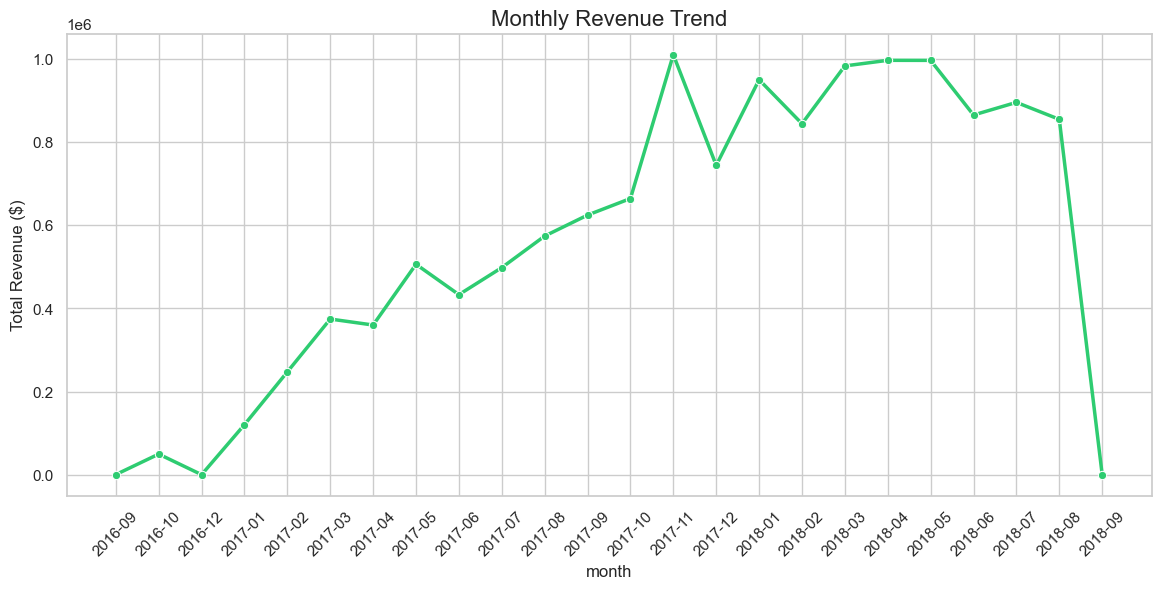

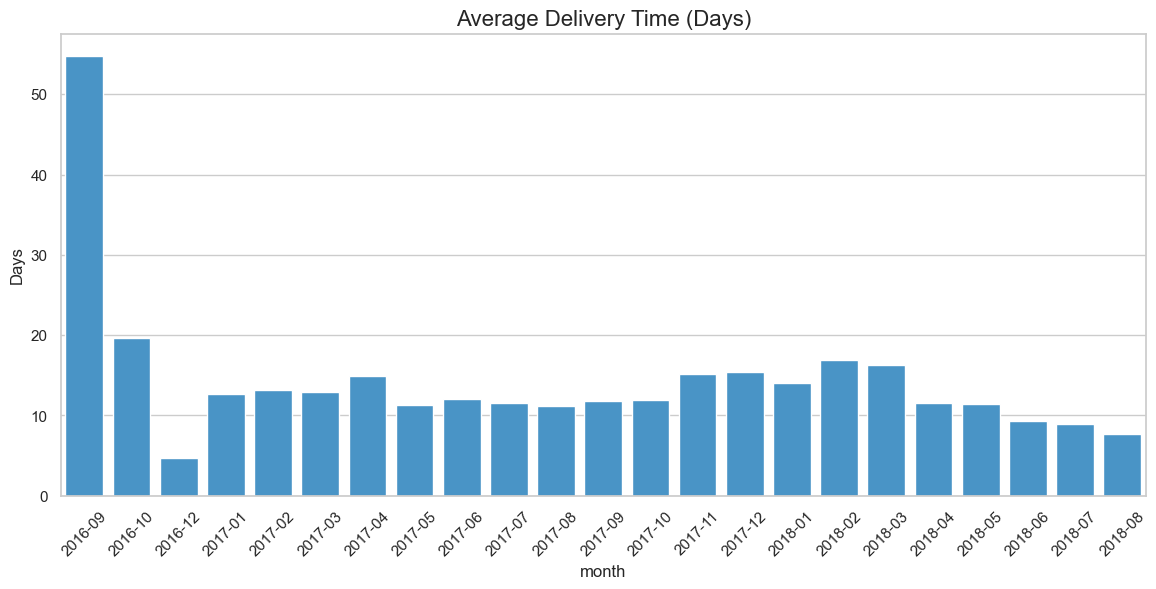

In [58]:
query_revenue = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    SUM(oi.price) AS total_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY month
"""

query_delivery = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS month,
    AVG(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)) AS avg_delivery_time
FROM orders
WHERE order_status = 'delivered' AND order_delivered_customer_date IS NOT NULL
GROUP BY month
"""

df_revenue = pd.read_sql_query(query_revenue, conn)
df_delivery = pd.read_sql_query(query_delivery, conn)

# Revenue Trend
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_revenue, x='month', y='total_revenue', marker='o', color='#2ecc71', linewidth=2.5)
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue ($)')
plt.show()

# Delivery Trend
plt.figure(figsize=(14, 6))
sns.barplot(data=df_delivery, x='month', y='avg_delivery_time', color='#3498db')
plt.title('Average Delivery Time (Days)')
plt.xticks(rotation=45)
plt.ylabel('Days')
plt.show()

## 6. Geographic Revenue Distribution
Understanding where our revenue is concentrated helps in targeted marketing and logistics optimization.

C:\Users\medoc\AppData\Local\Temp\ipykernel_25056\1174284059.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




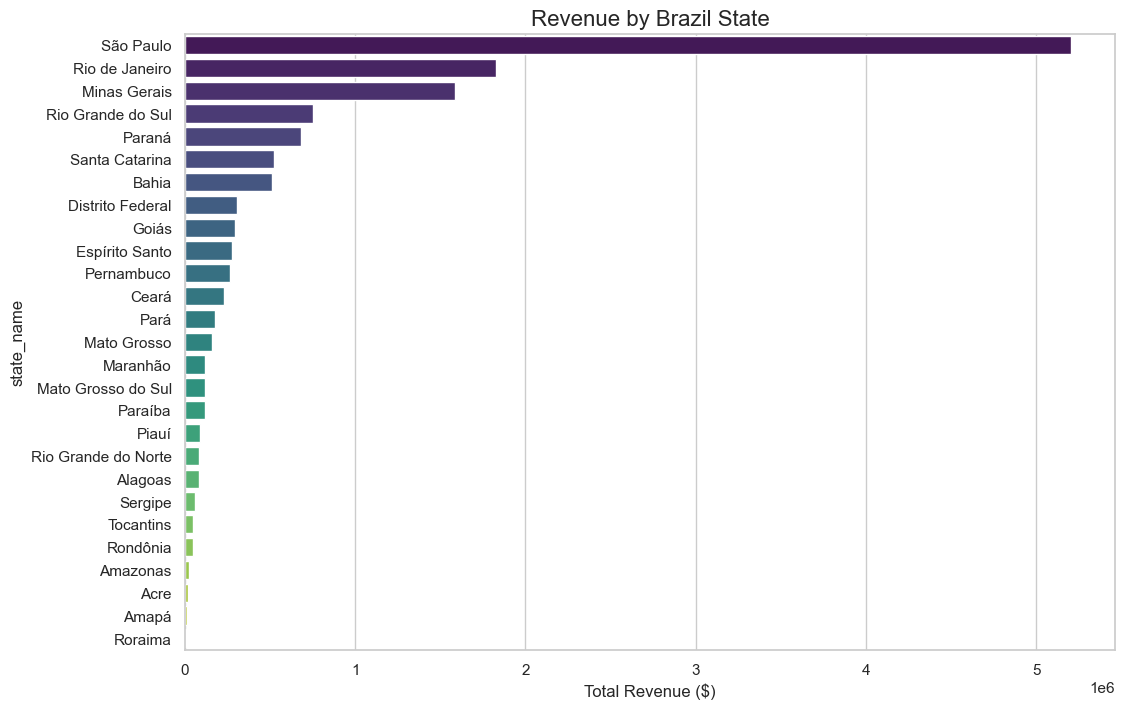

In [59]:
query_state = """
SELECT c.customer_state AS state_code, SUM(oi.price) AS total_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY state_code
ORDER BY total_revenue DESC
"""

df_state = pd.read_sql_query(query_state, conn)
df_state['state_name'] = df_state['state_code'].map(brazil_states_dict)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_state, x='total_revenue', y='state_name', palette='viridis')
plt.title('Revenue by Brazil State')
plt.xlabel('Total Revenue ($)')
plt.show()

## 7. Customer Satisfaction Analysis
Customer feedback is our primary sensor for quality control. High satisfaction scores are a leading indicator of brand loyalty.

C:\Users\medoc\AppData\Local\Temp\ipykernel_25056\543657706.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




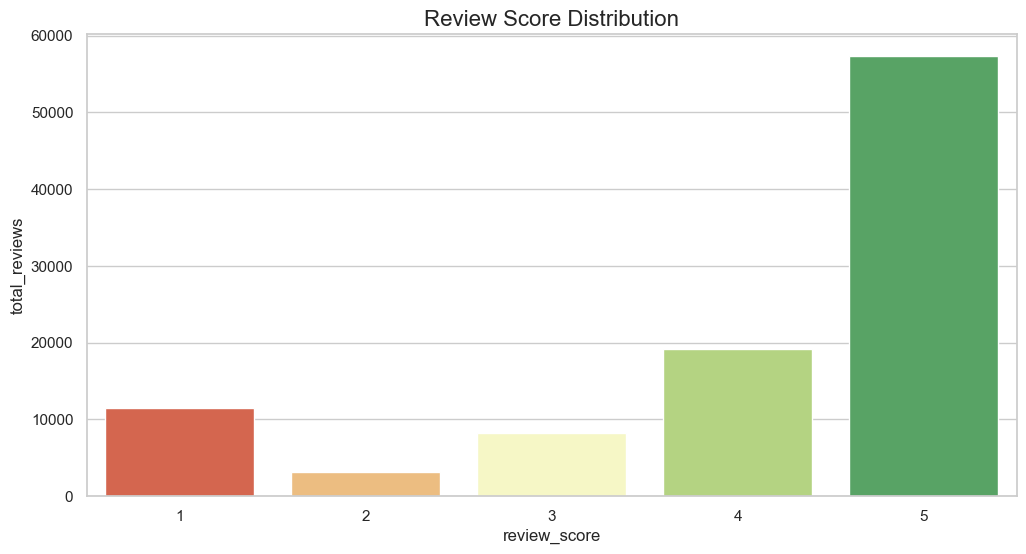

In [60]:
query_reviews = """
SELECT review_score, COUNT(review_id) AS total_reviews
FROM order_reviews
GROUP BY review_score
"""

df_reviews = pd.read_sql_query(query_reviews, conn)
sns.barplot(data=df_reviews, x='review_score', y='total_reviews', palette='RdYlGn')
plt.title('Review Score Distribution')
plt.show()

## 8. Marketplace Mechanics
Analyzing how people pay and who is selling helps us understand the health of the marketplace ecosystem.

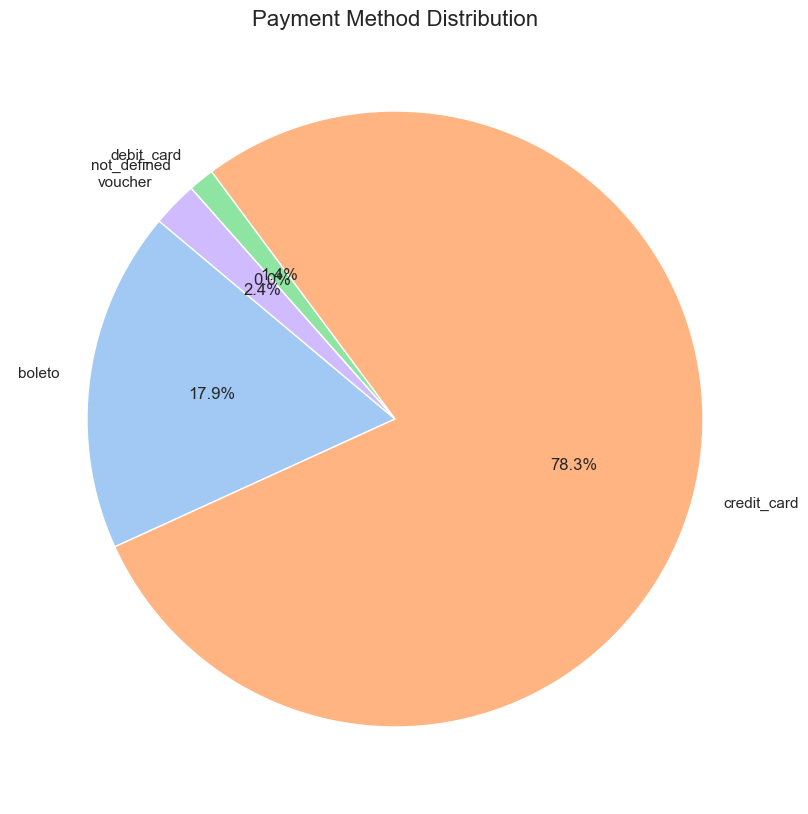

In [61]:
query_payments = """SELECT payment_type, SUM(payment_value) AS total_value FROM order_payments GROUP BY payment_type"""
df_payments = pd.read_sql_query(query_payments, conn)

plt.figure(figsize=(10, 10))
plt.pie(df_payments['total_value'], labels=df_payments['payment_type'], autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Distribution')
plt.show()

## 9. Conclusion
The Olist dataset reveals a dynamic marketplace with strong geographic concentration and clear growth cycles. By optimizing logistics and maintaining high satisfaction scores, Olist continues to dominate the Brazilian e-commerce landscape.